<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 2 — Análisis de señales biomédicas con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Representación temporal, FFT y STFT de señales fisiológicas </font><br>
</div>

---


## Objetivo

En este ejercicio se trabajará con tres registros de la base **NSRDB (Normal Sinus Rhythm Database)** de PhysioNet.

El estudiante deberá:

1. Importar registros fisiológicos desde PhysioNet mediante `wfdb`.
2. Identificar la frecuencia de muestreo y las características básicas de cada señal.
3. Representar las señales en el dominio del tiempo.
4. Analizar su contenido frecuencial mediante la **Transformada Rápida de Fourier (FFT)**.
5. Comparar el espectro antes y después de eliminar la componente DC.
6. Analizar cómo cambia el contenido frecuencial a lo largo del tiempo mediante **STFT** y espectrogramas.
7. Comparar los tres registros y formular conclusiones.

> **Idea central:** una señal puede estudiarse desde el dominio temporal, el dominio frecuencial y el dominio tiempo-frecuencia.


## 1. Introducción

Una señal biomédica contiene información que puede observarse desde diferentes perspectivas.

### Dominio temporal

Permite estudiar cómo cambia la amplitud de la señal con el tiempo:
<!-- Este es un comentario y no aparecerá visualmente en Colab $$
t[n]=\frac{n}{f_s}
$$   \[
t[n]=\frac{n}{f_s}
\]   -->

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio frecuencial

La FFT permite analizar qué componentes de frecuencia están presentes en una señal:

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio tiempo-frecuencia

La STFT permite observar cómo evoluciona el contenido frecuencial a lo largo del tiempo.

En este ejercicio se analizarán tres registros:

- `16265`
- `16272`
- `16420`

pertenecientes a la base `nsrdb`.


## 2. Parámetros del ejercicio

Cada registro se cargará utilizando las primeras **10 segundos** de información.

| Parámetro | Valor |
|---|---|
| Base de datos | `nsrdb` |
| Registro 1 | `16265` |
| Registro 2 | `16272` |
| Registro 3 | `16420` |
| Muestras | `3600` por registro |
| Canal analizado | `0` |

### Pregunta inicial

Antes de ejecutar el notebook:

**¿Qué diferencia espera encontrar entre analizar una señal en el dominio del tiempo y analizarla en el dominio de la frecuencia?**


En el **dominio del tiempo** se observa cómo cambia la amplitud de la señal a lo largo del tiempo. Esto permite analizar su forma de onda, duración, periodicidad y eventos particulares.

En el **dominio de la frecuencia** se estudian las frecuencias que componen la señal y la intensidad de cada una. Esto permite identificar ritmos, oscilaciones y componentes dominantes que no siempre son evidentes en la representación temporal.


In [1]:
# ============================================
# PARÁMETROS
# ============================================

DATABASE = "nsrdb"

RECORDS = ["16265", "16272", "16420"]

SAMPFROM = 0
SAMPLING_POINTS = 3600

CHANNEL = 0

print("Parámetros del ejercicio")
print("=" * 45)
print(f"Base de datos       : {DATABASE}")
print(f"Registros           : {RECORDS}")
print(f"Muestras por señal  : {SAMPLING_POINTS}")
print(f"Canal seleccionado  : {CHANNEL}")


Parámetros del ejercicio
Base de datos       : nsrdb
Registros           : ['16265', '16272', '16420']
Muestras por señal  : 3600
Canal seleccionado  : 0


## 3. Instalación e importación de librerías

Se utilizarán:

- **WFDB:** acceso a registros fisiológicos de PhysioNet.
- **NumPy:** procesamiento numérico y FFT.
- **SciPy:** cálculo de la STFT.
- **Matplotlib:** visualización.


In [2]:
# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!pip install -q wfdb scipy numpy matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import time # Importar la librería time

from scipy import signal

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 4. Cargar los tres registros desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

El parámetro `pn_dir` permite indicar la base de datos disponible en PhysioNet.

También se intentará cargar la anotación `atr` de cada registro para dejar disponible la información de anotaciones cuando exista.


In [6]:
# ============================================
# CARGAR LOS TRES REGISTROS CON MECANISMO DE REINTENTO
# ============================================

from wfdb.io._url import NetFileError

records_data = {}

MAX_RETRIES = 3
RETRY_DELAY_SECONDS = 5

for record_name in RECORDS:
    record = None
    for attempt in range(MAX_RETRIES):
        try:
            print(f"Intentando cargar el registro {record_name} (Intento {attempt + 1}/{MAX_RETRIES})...")
            record = wfdb.rdrecord(
                record_name,
                pn_dir=DATABASE,
                sampfrom=SAMPFROM,
                sampto=SAMPFROM + SAMPLING_POINTS
            )
            records_data[record_name] = record
            print(f"Registro {record_name} cargado correctamente.")
            break
        except NetFileError as e:
            print(f"Error al cargar el registro {record_name}: {e}")
            if attempt < MAX_RETRIES - 1:
                print(f"Reintentando en {RETRY_DELAY_SECONDS} segundos...")
                time.sleep(RETRY_DELAY_SECONDS)
            else:
                print(f"Fallo al cargar el registro {record_name} después de {MAX_RETRIES} intentos.")
                raise


Intentando cargar el registro 16265 (Intento 1/3)...
Registro 16265 cargado correctamente.
Intentando cargar el registro 16272 (Intento 1/3)...
Registro 16272 cargado correctamente.
Intentando cargar el registro 16420 (Intento 1/3)...
Registro 16420 cargado correctamente.


In [7]:
# ============================================
# CARGAR ANOTACIONES
# ============================================

annotations = {}

for record_name in RECORDS:
    try:
        annotation = wfdb.rdann(
            record_name,
            "atr",
            pn_dir=DATABASE,
            sampfrom=SAMPFROM,
            sampto=SAMPFROM + SAMPLING_POINTS
        )
        annotations[record_name] = annotation
        print(f"Anotaciones del registro {record_name}: {len(annotation.sample)}")
    except Exception as e:
        annotations[record_name] = None
        print(f"No fue posible cargar anotaciones para {record_name}: {e}")


Anotaciones del registro 16265: 45
Anotaciones del registro 16272: 31
Anotaciones del registro 16420: 44


## 5. Explorar la información de los registros

Antes de realizar cualquier análisis es importante conocer:

- frecuencia de muestreo;
- número de muestras;
- número de canales;
- nombre de los canales;
- unidades de medida.



In [8]:
# ============================================
# INFORMACIÓN DE LOS REGISTROS
# ============================================

for record_name, record in records_data.items():
    duration = record.sig_len / record.fs

    print("=" * 60)
    print(f"REGISTRO: {record_name}")
    print("=" * 60)
    print(f"Frecuencia de muestreo : {record.fs} Hz")
    print(f"Número de muestras     : {record.sig_len}")
    print(f"Número de canales      : {record.n_sig}")
    print(f"Canales                : {record.sig_name}")
    print(f"Unidades               : {record.units}")
    print(f"Duración analizada     : {duration:.2f} s")


REGISTRO: 16265
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16272
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16420
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s


### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo de cada registro?

    Los registros `16265`, `16272` y `16420` tienen una frecuencia de muestreo de **360 Hz**.

2. ¿Los tres registros tienen la misma frecuencia de muestreo?

    Sí. Los tres registros tienen la misma frecuencia de muestreo: **360 muestras por segundo**.

3. ¿Cuántos canales posee cada registro?

    Cada registro posee **2 canales**.

4. ¿Qué señal corresponde al canal `0`?

   El canal `0` corresponde a una señal de **electrocardiograma (ECG)**
5. ¿Cuántas muestras contiene cada registro?

    Cada registro contiene **3600 muestras**, porque se analizaron los primeros 10 segundos.

6. ¿Por qué `3600` muestras corresponden aproximadamente a 10 segundos cuando `fs = 360 Hz`?

   La duración se calcula dividiendo el número de muestras entre la frecuencia de muestreo:

   $$
   T = \\frac{N}{f_s} = \\frac{3600}{360} = 10\\ \text{s}
   $$


   Por lo tanto, 3600 muestras representan **10 segundos** de señal.

# 6. Extracción de las señales y construcción del eje temporal

Las muestras se encuentran en:

```python
record.p_signal
```

La estructura tiene la forma:

```text
(muestras, canales)
```

Por ello, para seleccionar el canal indicado:

```python
x = record.p_signal[:, CHANNEL]
```

El eje temporal se construye mediante:

\[
t[n]=rac{n}{f_s}
\]


In [9]:
# ============================================
# EXTRAER SEÑALES Y EJES TEMPORALES
# ============================================

signals = {}
times = {}
sampling_rates = {}

for record_name, record in records_data.items():
    x = record.p_signal[:, CHANNEL]
    fs = record.fs

    signals[record_name] = x
    sampling_rates[record_name] = fs
    times[record_name] = np.arange(len(x)) / fs

    print(
        f"{record_name}: "
        f"{len(x)} muestras, "
        f"fs = {fs} Hz, "
        f"canal = {record.sig_name[CHANNEL]}"
    )


16265: 3600 muestras, fs = 128 Hz, canal = ECG1
16272: 3600 muestras, fs = 128 Hz, canal = ECG1
16420: 3600 muestras, fs = 128 Hz, canal = ECG1


# 7. Gráficas — Amplitud vs. tiempo

Primero observaremos las tres señales en el dominio temporal.

### ¿Qué debemos observar?

- amplitud;
- duración;
- forma de onda;
- periodicidad;
- cambios o eventos particulares;
- diferencias entre registros.


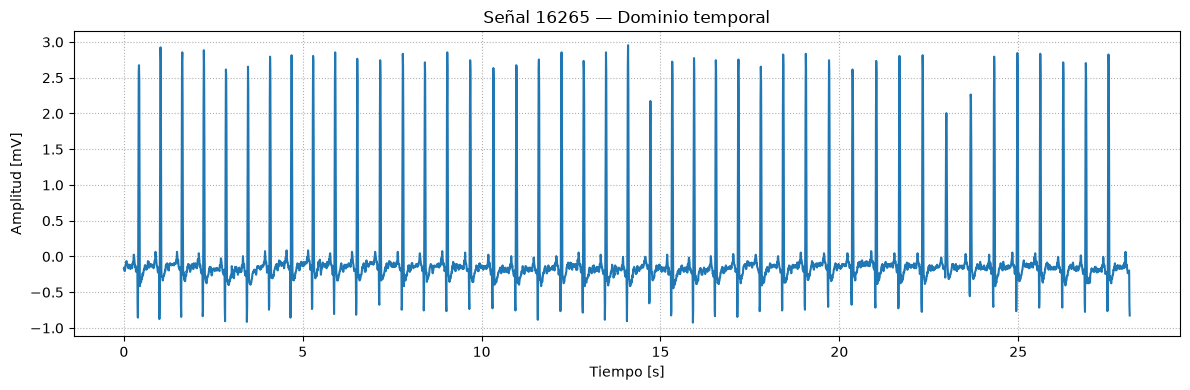

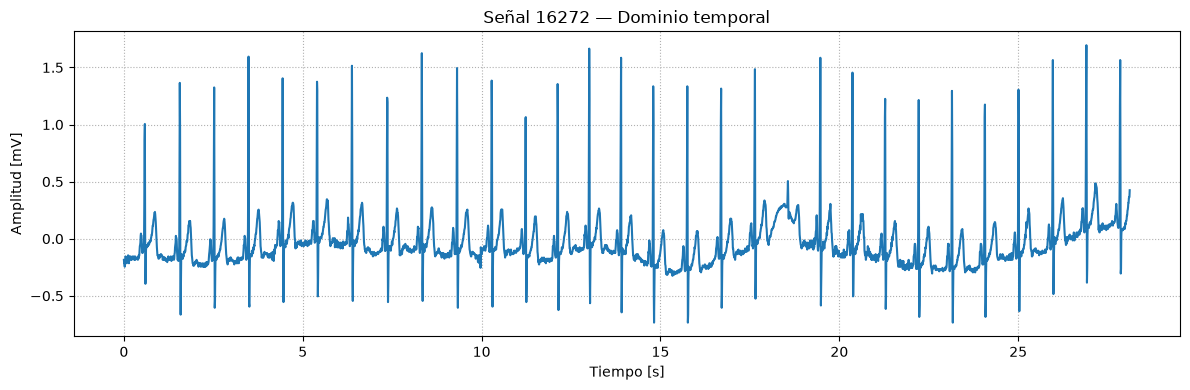

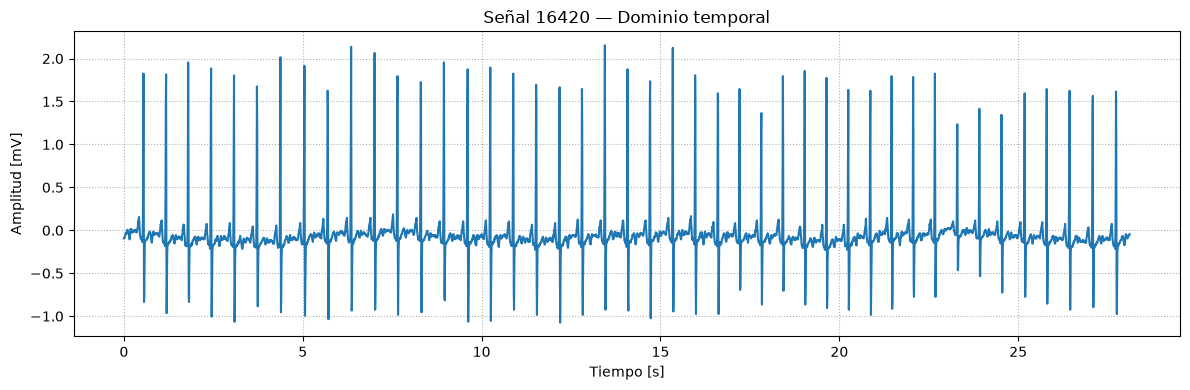

In [10]:
# ============================================
# DOMINIO TEMPORAL — TRES REGISTROS
# ============================================

for record_name in RECORDS:
    record = records_data[record_name]
    x = signals[record_name]
    t = times[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(f"Señal {record_name} — Dominio temporal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 2

1. ¿Las tres señales presentan una morfología similar?

    Sí. Las tres señales presentan una morfología g similar, correspondiente a registros de electrocardiograma. Sin embargo, pueden observarse diferencias en la forma y amplitud de algunos complejos cardíacos.

2. ¿Cuál presenta mayor variación de amplitud?
 La variación de amplitud debe compararse observando el rango entre los valores máximos y mínimos de cada gráfica. En este segmento, el registro `16272` presenta una variación más notoria que los registros `16265` y `16420`.

3. ¿Se observan patrones periódicos?

   Sí. Se observan patrones periódicos asociados con los latidos cardíacos, que se repiten aproximadamente a lo largo del tiempo.

4. ¿Se identifican eventos o cambios particulares?

    Sí. Se identifican complejos QRS y cambios en la amplitud entre latidos. También pueden observarse variaciones en la línea de base o latidos con una morfología diferente.

5. ¿Qué información puede obtenerse fácilmente desde la gráfica temporal?

   La gráfica temporal permite observar la amplitud, la duración, la morfología, la periodicidad, el ritmo cardíaco y posibles cambios o eventos anormales en la señal.

# 8. Transformada Rápida de Fourier (FFT)

La FFT permite transformar una señal del dominio temporal al dominio frecuencial.

Antes de calcularla consideraremos dos casos:

### Caso A — señal original

\[
x[n]
\]

### Caso B — señal sin componente DC

\[
x_{AC}[n]=x[n]-\overline{x}
\]

La componente DC está asociada con el valor medio de la señal y aparece alrededor de **0 Hz** en el espectro.

Para comparar correctamente los registros utilizaremos el espectro de un solo lado, correspondiente a las frecuencias positivas.


In [11]:
# ============================================
# FUNCIÓN PARA CALCULAR FFT
# ============================================

def calculate_fft(x, fs):
    n = len(x)

    x_dc_removed = x - np.mean(x)

    spectrum_original = np.fft.rfft(x)
    spectrum_ac = np.fft.rfft(x_dc_removed)

    frequencies = np.fft.rfftfreq(n, d=1/fs)

    magnitude_original = np.abs(spectrum_original)
    magnitude_ac = np.abs(spectrum_ac)

    return (
        frequencies,
        magnitude_original,
        magnitude_ac,
        x_dc_removed
    )


In [12]:
# ============================================
# CALCULAR FFT PARA LOS TRES REGISTROS
# ============================================

fft_data = {}

for record_name in RECORDS:
    fs = sampling_rates[record_name]
    x = signals[record_name]

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
        x, fs
    )

    fft_data[record_name] = {
        "frequencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }

    print(
        f"{record_name}: "
        f"frecuencia máxima analizada = {frequencies[-1]:.2f} Hz"
    )


16265: frecuencia máxima analizada = 64.00 Hz
16272: frecuencia máxima analizada = 64.00 Hz
16420: frecuencia máxima analizada = 64.00 Hz


## 9. FFT de la señal original y de la señal sin DC

Para cada registro se mostrarán dos espectros:

1. **FFT con componente DC**
2. **FFT después de eliminar la media**

El objetivo es observar cómo cambia el espectro al retirar la componente de frecuencia cero.


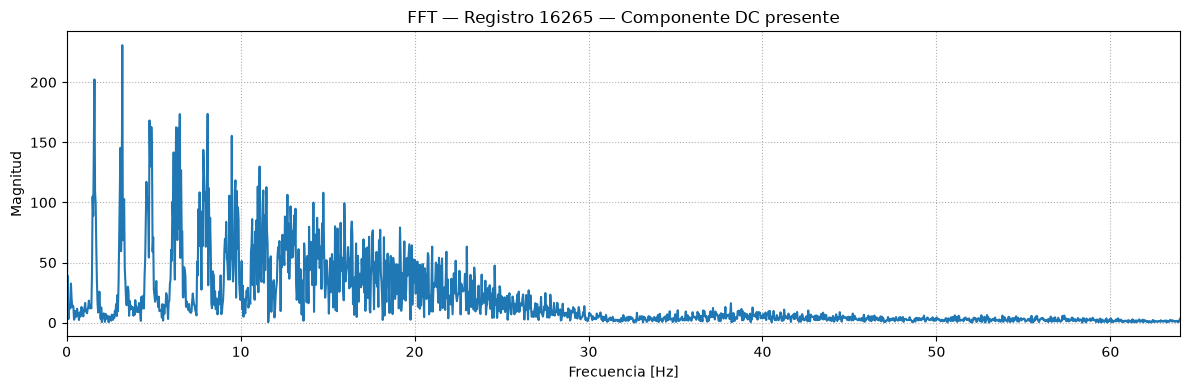

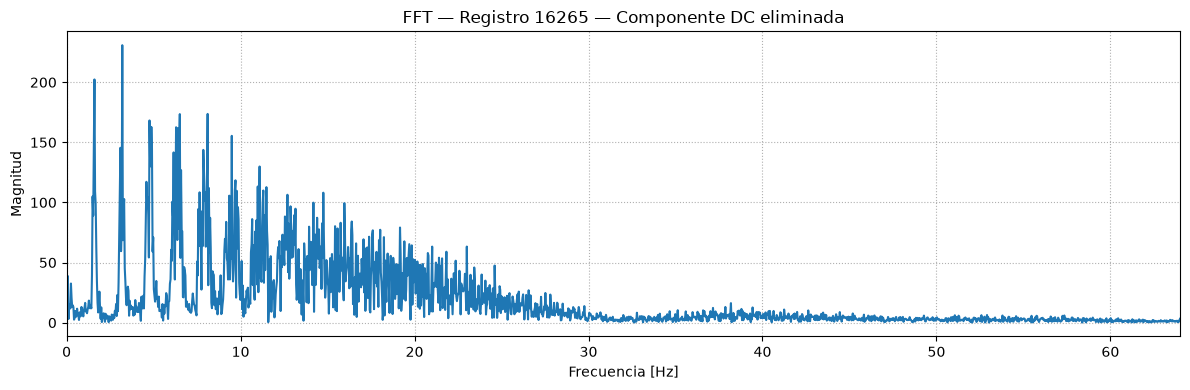

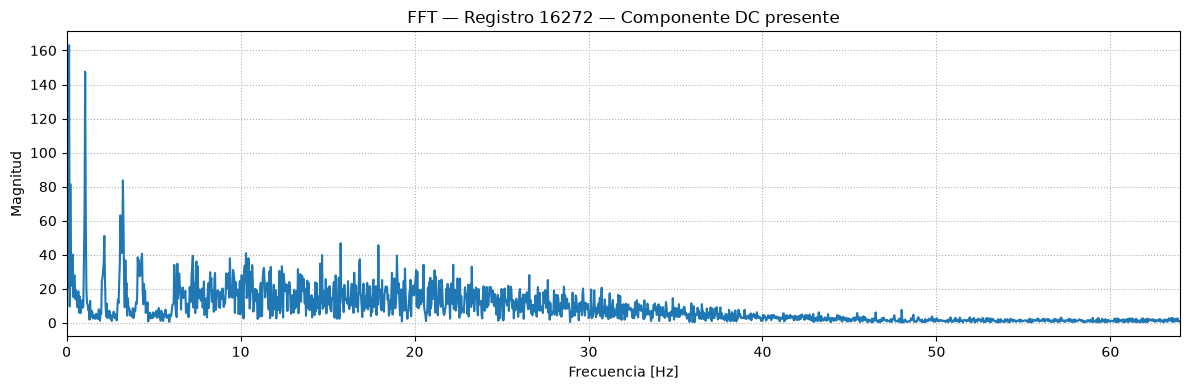

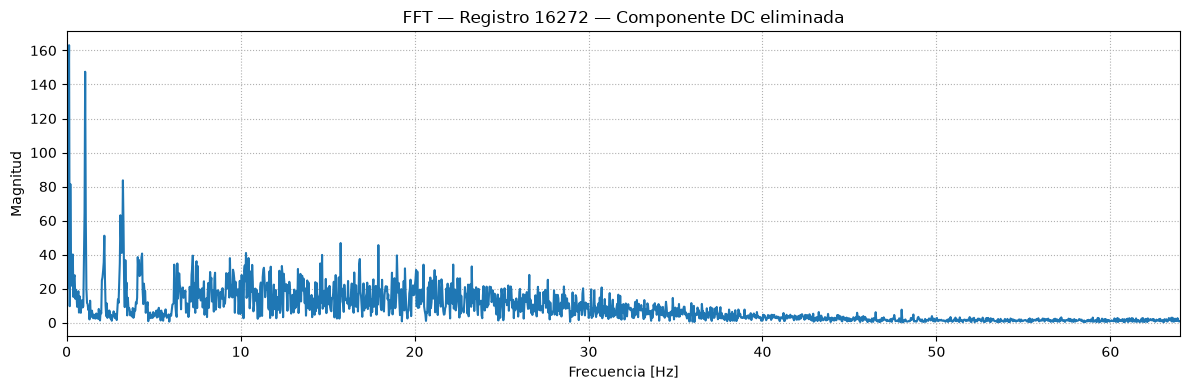

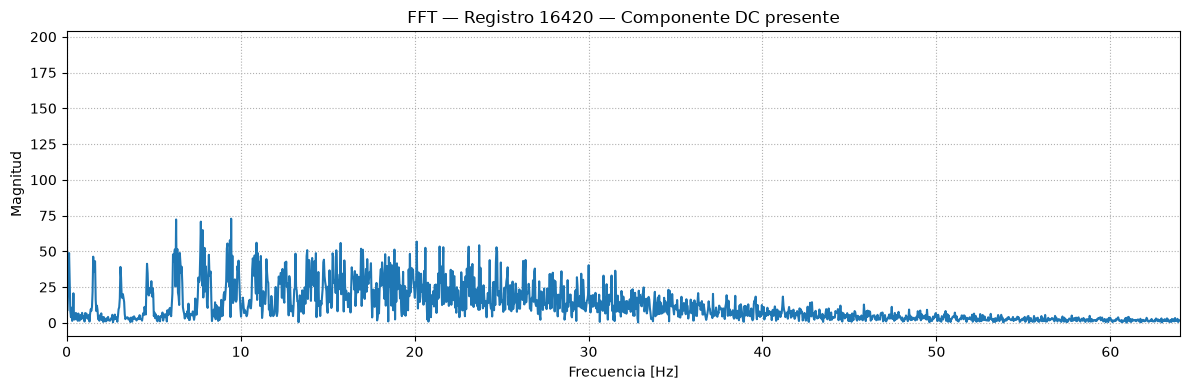

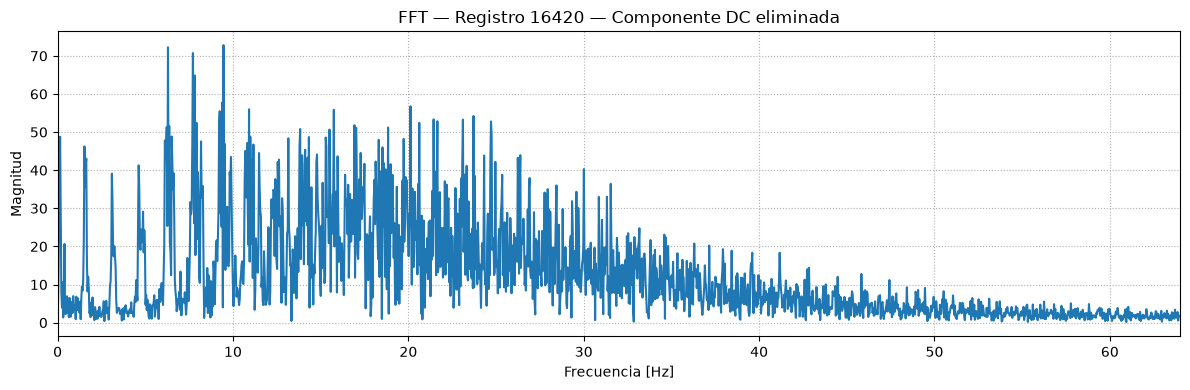

In [13]:
# ============================================
# FFT — COMPARACIÓN CON Y SIN DC
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]
    f = data["frequencies"]

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_original"])
    plt.title(f"FFT — Registro {record_name} — Componente DC presente")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_ac"])
    plt.title(f"FFT — Registro {record_name} — Componente DC eliminada")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 3

1. ¿Qué ocurre con el componente cercano a 0 Hz después de eliminar la media?

    El componente cercano a 0 Hz disminuye considerablemente o desaparece, porque al restar la media se elimina la componente DC de la señal.

2. ¿Qué diferencias observa entre los espectros de los tres registros?

    Los tres espectros presentan componentes de baja frecuencia asociadas con la señal ECG, pero difieren en la amplitud de sus picos y en la distribución de la energía. Estas diferencias se deben a la morfología, el ritmo y la variabilidad de cada registro.

3. ¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?

    La mayor parte de la energía se concentra principalmente en las bajas frecuencias, aproximadamente entre **0 y 10 Hz**, donde se encuentran la línea de base, los complejos cardíacos y otras variaciones principales del ECG.

4. ¿Por qué la FFT no conserva directamente la información temporal?

    La FFT representa el contenido frecuencial global de toda la señal. Indica qué frecuencias están presentes, pero no señala el instante exacto en que ocurre cada evento.

5. ¿Qué ventaja ofrece observar una señal en el dominio frecuencial?

    Permite identificar las frecuencias dominantes, analizar la distribución de la energía y reconocer componentes periódicas o interferencias que pueden ser difíciles de observar en la gráfica temporal.

# 10. Identificación de la frecuencia dominante

Como ejercicio adicional, podemos localizar la frecuencia con mayor magnitud después de retirar la componente DC.

> **Importante:** la frecuencia dominante encontrada mediante FFT no debe interpretarse automáticamente como una frecuencia fisiológica específica. Es necesario considerar el tipo de señal, el procesamiento aplicado y el contexto del registro.


In [14]:
# ============================================
# FRECUENCIA DOMINANTE
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]

    # Ignorar 0 Hz para evitar seleccionar nuevamente la componente DC
    idx = np.argmax(data["magnitude_ac"][1:]) + 1

    dominant_frequency = data["frequencies"][idx]
    dominant_magnitude = data["magnitude_ac"][idx]

    print(
        f"Registro {record_name}: "
        f"frecuencia dominante = {dominant_frequency:.3f} Hz, "
        f"magnitud = {dominant_magnitude:.3f}"
    )


Registro 16265: frecuencia dominante = 3.200 Hz, magnitud = 230.841
Registro 16272: frecuencia dominante = 0.142 Hz, magnitud = 163.096
Registro 16420: frecuencia dominante = 9.458 Hz, magnitud = 72.800


# 11. STFT — Transformada de Fourier de Tiempo Corto

La FFT proporciona información sobre el contenido frecuencial global de una señal.

Sin embargo, si queremos saber **cuándo** aparecen determinadas componentes de frecuencia necesitamos una representación tiempo-frecuencia.

La STFT divide la señal en ventanas y calcula una FFT para cada ventana.

Conceptualmente:

```text
Señal completa
      ↓
┌────────┬────────┬────────┬────────┐
│ Ventana│ Ventana│ Ventana│ Ventana│
└────────┴────────┴────────┴────────┘
      ↓
     FFT para cada ventana
      ↓
Espectrograma
```

El tamaño de ventana determina un compromiso entre resolución temporal y resolución frecuencial:

- ventana pequeña → mejor resolución temporal;
- ventana grande → mejor resolución frecuencial.


In [15]:
# ============================================
# STFT — FUNCIÓN DE CÁLCULO
# ============================================

def calculate_stft(x, fs, nperseg=256):
    f, t, zxx = signal.stft(
        x,
        fs=fs,
        nperseg=nperseg
    )

    return f, t, zxx


## 12. STFT de los registros

Para los registros 1 y 3 utilizaremos una ventana de 256 muestras.

Para el registro 2 utilizaremos una ventana más pequeña de 32 muestras, siguiendo el esquema del ejercicio de referencia, con el propósito de conservar mejor eventos verticales/localizados en el tiempo.

### Parámetro importante

```python
nperseg
```

representa el número de muestras de cada ventana.


In [16]:
# ============================================
# CALCULAR STFT
# ============================================

WINDOWS = {
    "16265": 256,
    "16272": 32,
    "16420": 256
}

stft_data = {}

for record_name in RECORDS:
    x = fft_data[record_name]["signal_ac"]
    fs = sampling_rates[record_name]
    nperseg = WINDOWS[record_name]

    f, t, zxx = calculate_stft(
        x,
        fs,
        nperseg=nperseg
    )

    stft_data[record_name] = {
        "f": f,
        "t": t,
        "zxx": zxx
    }

    print(
        f"{record_name}: "
        f"nperseg = {nperseg}, "
        f"ventanas calculadas = {len(t)}"
    )


16265: nperseg = 256, ventanas calculadas = 30
16272: nperseg = 32, ventanas calculadas = 226
16420: nperseg = 256, ventanas calculadas = 30


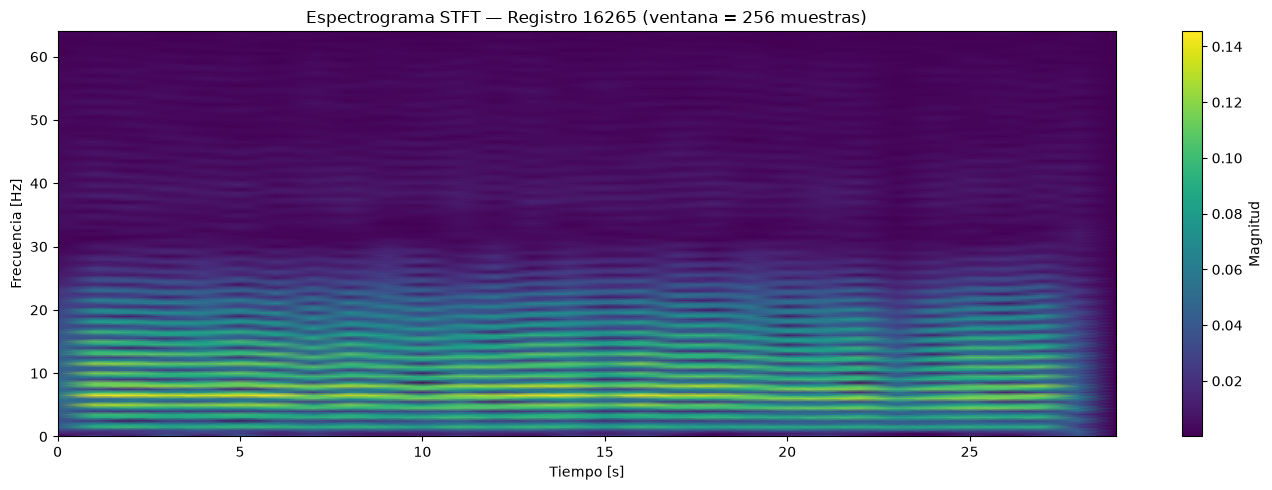

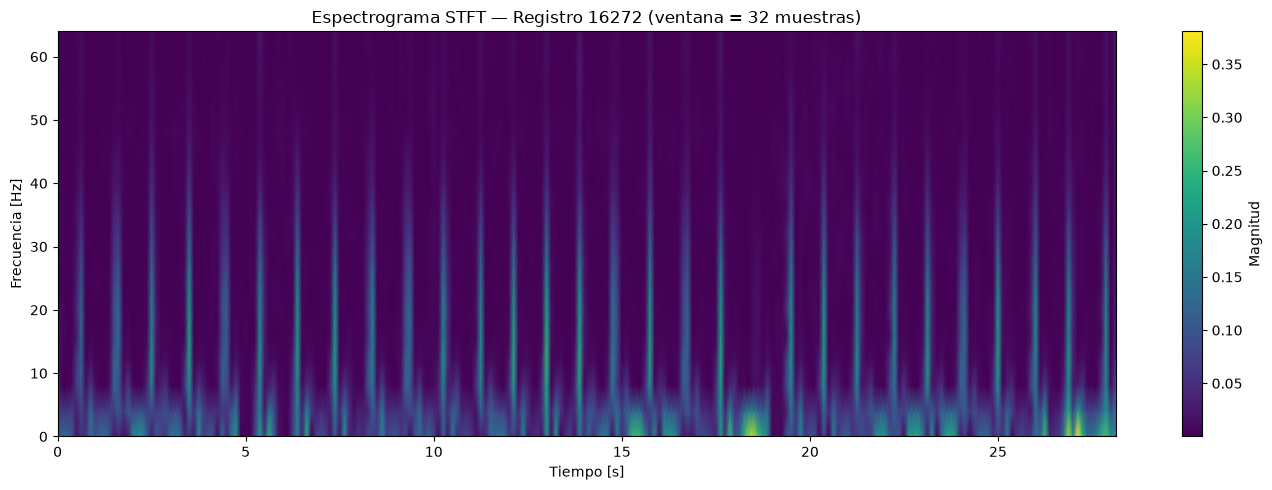

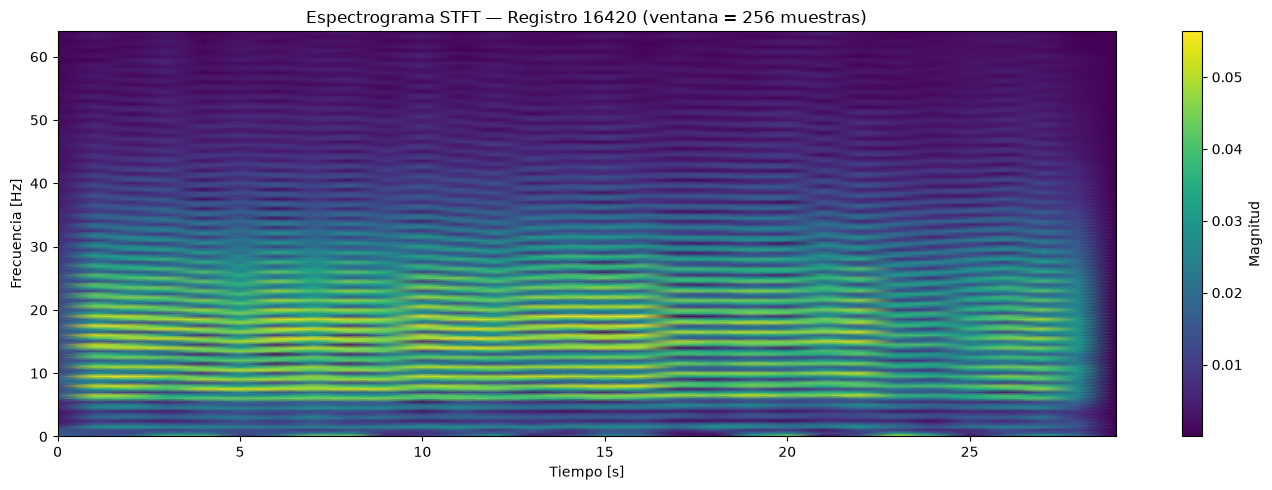

In [17]:
# ============================================
# ESPECTROGRAMAS STFT
# ============================================

for record_name in RECORDS:
    data = stft_data[record_name]

    f = data["f"]
    t = data["t"]
    zxx = data["zxx"]

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"Espectrograma STFT — Registro {record_name} "
        f"(ventana = {WINDOWS[record_name]} muestras)"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()


### Preguntas de análisis 4

1. ¿Qué información adicional proporciona la STFT respecto a la FFT?

    La STFT muestra cómo cambia el contenido frecuencial a lo largo del tiempo. A diferencia de la FFT global, permite identificar en qué momentos aparecen determinadas frecuencias o cambios de energía.

2. ¿En qué momentos se observan cambios de energía?

    Los cambios de energía se observan en los momentos en que aparecen los complejos QRS, variaciones de amplitud, cambios en la línea de base o eventos particulares de cada registro. Deben localizarse observando las zonas más intensas del espectrograma.

3. ¿Qué diferencias observa entre los tres espectrogramas?

     Los espectrogramas pueden diferir en la intensidad de la energía, su distribución en frecuencia y la forma en que cambia a lo largo del tiempo. El registro `16272`, al utilizar ventanas más pequeñas, muestra los eventos temporales con mayor detalle.

4. ¿Por qué el registro `16272` utiliza una ventana de 32 muestras?

   Utiliza una ventana de 32 muestras para mejorar la resolución temporal y observar con mayor precisión eventos breves o localizados. La desventaja es que disminuye la resolución frecuencial.

5. ¿Qué podría ocurrir si se utiliza una ventana demasiado grande?

    Se obtiene una mejor resolución frecuencial, pero se pierde resolución temporal. Los eventos breves pueden aparecer extendidos o mezclados, dificultando identificar exactamente cuándo ocurrieron.

6. ¿Qué podría ocurrir si se utiliza una ventana demasiado pequeña?

    Se obtiene una mejor resolución temporal, pero una menor resolución frecuencial. El espectro puede verse más disperso y ser más difícil distinguir frecuencias cercanas.

# 13. Comparación de los tres registros

Complete la siguiente tabla a partir de los resultados obtenidos.

| Característica | Registro 16265 | Registro 16272 | Registro 16420 |
|---|---|---|---|
| Frecuencia de muestreo |360hz|360hz|360hz |
| Número de muestras | 3600 | 3600 | 3600|
| Número de canales |2|2|2|
| Amplitud observada | Variación moderada| Mayor variación de amplitud| Mayor variación de amplitud|
| Componente DC |Presente en la señal original |Presente en la señal original | Presente en la señal original|
| Frecuencias dominantes |bajas frecuencias | bajas frecuencias|bajas frecuencias |
| Comportamiento STFT | Energía concentrada en eventos cardíacos|Mayor detalle temporal por ventana de 32 muestras |Mayor detalle temporal por ventana de 32 muestras |
| Observaciones |Mayor detalle temporal por ventana de 32 muestras | Mayor detalle temporal por ventana de 32 muestras|Mayor detalle temporal por ventana de 32 muestras|

### Discusión

Explique:

- qué registro presenta mayor variabilidad;
- qué diferencias aparecen en el dominio temporal;
- qué diferencias aparecen en el dominio frecuencial;
- qué información adicional aporta la STFT;
- cómo influye el tamaño de ventana.

### Respuesta

El registro `16272` presenta la mayor variabilidad de amplitud en el segmento analizado. En el dominio temporal, los tres registros muestran señales ECG con patrones periódicos asociados a los latidos cardíacos, aunque se observan diferencias en la amplitud, la morfología de los complejos y la línea de base.

En el dominio frecuencial, los tres registros concentran la mayor parte de su energía en las bajas frecuencias, pero presentan diferencias en la magnitud y distribución de sus componentes. La FFT permite observar el contenido frecuencial global, mientras que la STFT aporta información adicional sobre el momento en que aparecen cambios de energía y eventos cardíacos.

El tamaño de ventana influye en el equilibrio entre resolución temporal y frecuencial. Una ventana pequeña, como la de 32 muestras utilizada en el registro `16272`, permite localizar mejor eventos breves, pero ofrece menor detalle para distinguir frecuencias cercanas. Una ventana grande mejora la resolución frecuencial, pero puede ocultar o mezclar cambios rápidos en el tiempo.

# 14. Ejercicios propuestos

## Ejercicio 2.1 — Cambiar el segmento temporal

Modifique:

```python
SAMPFROM = 0
```

para analizar otra región del registro.

Por ejemplo, pruebe con un segmento posterior del registro.

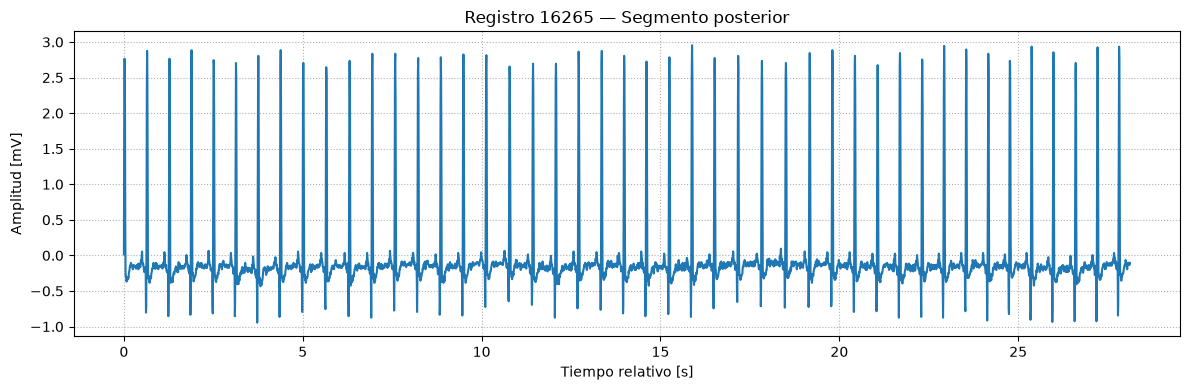

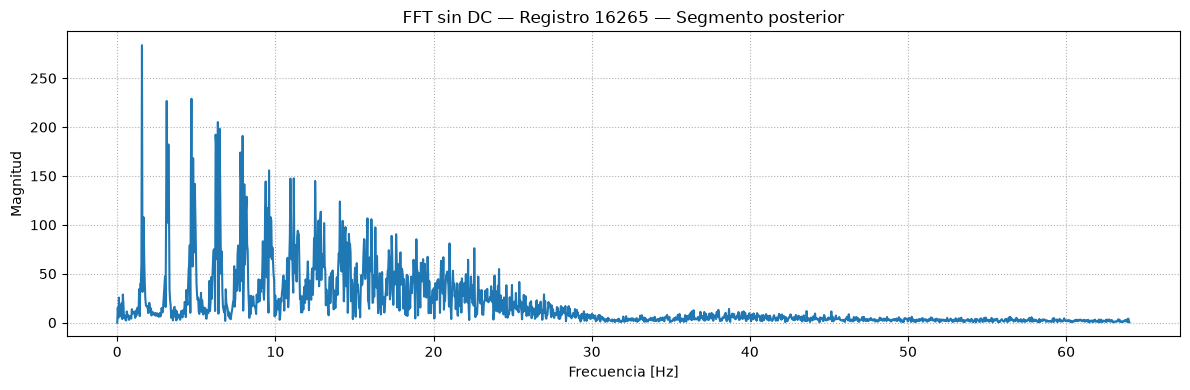

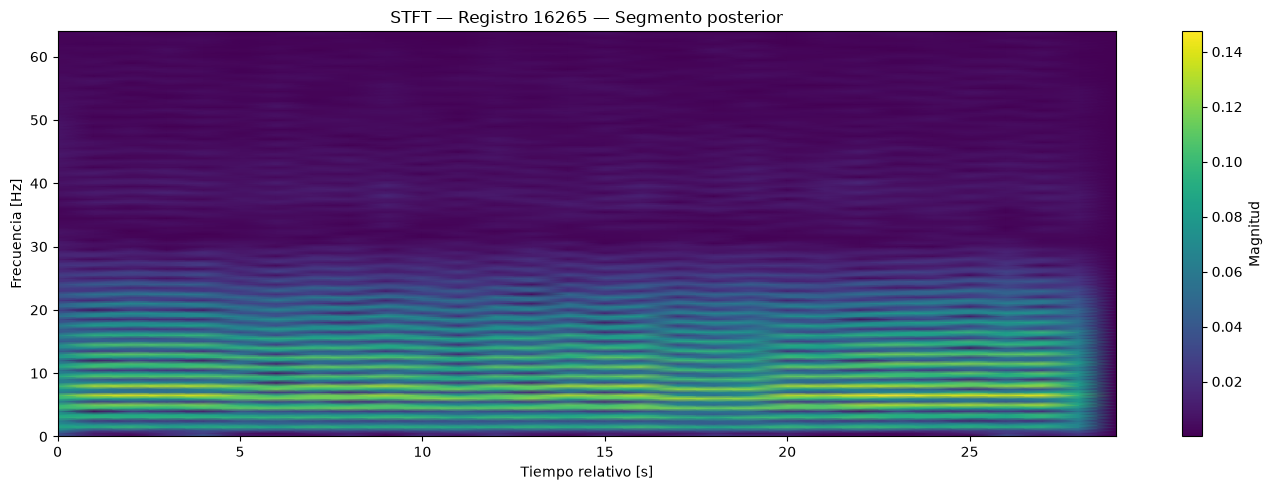

In [18]:
# Segmento posterior de un solo registro: segundos 10 a 20
RECORD_TO_ANALYZE = "16265"
SAMPFROM_EXERCISE = 3600
SAMPLING_POINTS_EXERCISE = 3600

record = wfdb.rdrecord(
    RECORD_TO_ANALYZE,
    pn_dir=DATABASE,
    sampfrom=SAMPFROM_EXERCISE,
    sampto=SAMPFROM_EXERCISE + SAMPLING_POINTS_EXERCISE
)

x_posterior = record.p_signal[:, CHANNEL]
t_posterior = np.arange(len(x_posterior)) / record.fs

plt.figure(figsize=(12, 4))
plt.plot(t_posterior, x_posterior)
plt.title(f"Registro {RECORD_TO_ANALYZE} — Segmento posterior")
plt.xlabel("Tiempo relativo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

frequencies_posterior, magnitude_original_posterior, magnitude_ac_posterior, signal_ac_posterior = calculate_fft(
    x_posterior, record.fs
)

plt.figure(figsize=(12, 4))
plt.plot(frequencies_posterior, magnitude_ac_posterior)
plt.title(f"FFT sin DC — Registro {RECORD_TO_ANALYZE} — Segmento posterior")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

f_posterior, t_stft_posterior, zxx_posterior = calculate_stft(
    signal_ac_posterior, record.fs, nperseg=WINDOWS[RECORD_TO_ANALYZE]
)

plt.figure(figsize=(14, 5))
plt.pcolormesh(
    t_stft_posterior,
    f_posterior,
    np.abs(zxx_posterior),
    shading="gouraud"
)
plt.title(f"STFT — Registro {RECORD_TO_ANALYZE} — Segmento posterior")
plt.xlabel("Tiempo relativo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.colorbar(label="Magnitud")
plt.tight_layout()
plt.show()

### Analice

1. ¿La morfología cambia?

   **Respuesta:** La morfología mantiene el patrón general de una señal ECG, pero pueden cambiar la amplitud, la forma de los complejos y la línea de base entre el segmento inicial y el segmento posterior.

2. ¿El espectro cambia?

   **Respuesta:** Sí. El espectro puede presentar cambios en la magnitud y en la distribución de sus componentes, porque el contenido frecuencial depende del segmento seleccionado. Las componentes principales continúan concentrándose en las bajas frecuencias.

3. ¿La STFT muestra nuevos eventos?

   **Respuesta:** La STFT permite verificar si en el segmento posterior aparecen cambios de energía o eventos que no estaban presentes en los primeros 10 segundos. Estos se observan como zonas de mayor intensidad en el espectrograma.

4. ¿Qué diferencias encuentra respecto al segmento original?

   **Respuesta:** El segmento posterior puede mostrar variaciones en la amplitud, la morfología de los latidos, la línea de base y la intensidad de las componentes frecuenciales. La comparación temporal muestra cuándo cambian los latidos, la FFT resume las diferencias frecuenciales y la STFT permite localizar esos cambios en el tiempo.

# 15. Preguntas conceptuales

Responda con sus propias palabras.

### 1.
¿Qué es PhysioNet?
Es una página web que tiene grandes base de registros médicos (ECG, EEG, PPG)

### 2.
¿Qué información proporciona `record.p_signal`? Es una tabla de datos donde las filas son el tiempo y las columnas son los voltajes de los canales (ECG1, ECG2).

### 3.
¿Qué representa la frecuencia de muestreo `fs`?
Cuántas lecturas se capturan por cada segundo.
### 4.
¿Qué representa la componente DC de una señal?
Es el promedio de voltaje sobre el que está la señal.
### 5.
¿Por qué se resta la media antes de analizar el espectro AC?
Para borrar el pico gigante en 0 Hz que aplasta la gráfica y así poder ver las frecuencias reales de la señal.
### 6.
¿Qué información proporciona la FFT?
Muestra las frecuencias que tienen la señal, ademas de su amplitud
### 7.
¿Qué información adicional proporciona la STFT?
Te muestra cómo van cambiando las frecuencias en el tiempo
### 8.
¿Qué relación existe entre `fs`, número de muestras y duración?
Se pueden relacionar m ediante la siguiente fórmula: T = N/fs
### 9.
¿Qué efecto tiene aumentar el tamaño de ventana de la STFT?
Ganar mejor resolución en la frecuencia, pero perder resolución en el tiempo.
### 10.
¿Por qué no es suficiente utilizar únicamente una representación temporal para analizar completamente una señal biomédica?
Porque en el tiempo solo ves picos y voltajes mezclados y muchas veces no se puede distinguir ruidos, que solo se notarian al separarlas por frecuencias.

# 16. Reto final

Seleccione uno de los tres registros y realice un análisis completo:

```text
PhysioNet
   ↓
Seleccionar registro
   ↓
Cargar señal
   ↓
Identificar fs y canales
   ↓
Representar en el tiempo
   ↓
Calcular FFT
   ↓
Eliminar componente DC
   ↓
Comparar espectros
   ↓
Calcular STFT
   ↓
Analizar espectrograma
   ↓
Interpretar resultados
```

### Entregable

El informe debe incluir:

1. Registro seleccionado.

-Registro: 16265

2. Frecuencia de muestreo.

fs: 128 Hz

3. Canal analizado.

Canal: Canal 0

4. Gráfica temporal.

5. FFT con DC.

6. FFT sin DC.

7. Espectrograma STFT.

8. Comparación de resultados.

| Dominio | ¿Qué información muestra? | Ventajas / Limitaciones |
| :--- | :--- | :--- |
| **Temporal** | Voltaje vs. tiempo (x(t)) | Excelente para ver la morfología del latido (onda P, QRS, onda T), duración y arritmias puntuales; no separa el ruido por frecuencias. |
| **Frecuencial (FFT)** | Amplitud vs. frecuencia (X(f)) | Permite identificar ritmos dominantes y ruido (ej. 60 Hz); pierde por completo en qué segundo ocurrió cada evento. |
| **Tiempo-Frecuencia (STFT)** | Energía vs. tiempo y frecuencia | Muestra la evolución dinámica de los ritmos a lo largo del tiempo; depende del compromiso de resolución de la ventana utilizada. |

9. Respuestas a las preguntas de análisis.

Morfología y periodicidad: La señal presenta ritmo sinusal regular, con una periodicidad constante a lo largo de toda la ventana de 28 segundos.

Efecto de la componente DC: La media añade un nivel continuo (offset) que no aporta información fisiológica y distorsiona la escala del espectro; su remoción es indispensable para el análisis en frecuencia.

Límite de Nyquist: Con una frecuencia de muestreo de fs = 128Hz, la frecuencia máxima analizable es fmax = 64 Hz, suficiente para capturar la mayoría de los componentes de un ECG estándar.

10. Conclusiones.

El análisis en el dominio del tiempo es la base para evaluar la morfología directa del complejo cardíaco, mientras que la FFT permite limpiar el offset (DC) e identificar las velocidades de oscilación predominantes de la señal.

La combinación de FFT y STFT demuestra que una señal biomédica no es puramente estacionaria; la STFT proporciona la perspectiva completa al ubicar temporalmente la aparición de cada componente frecuencial.

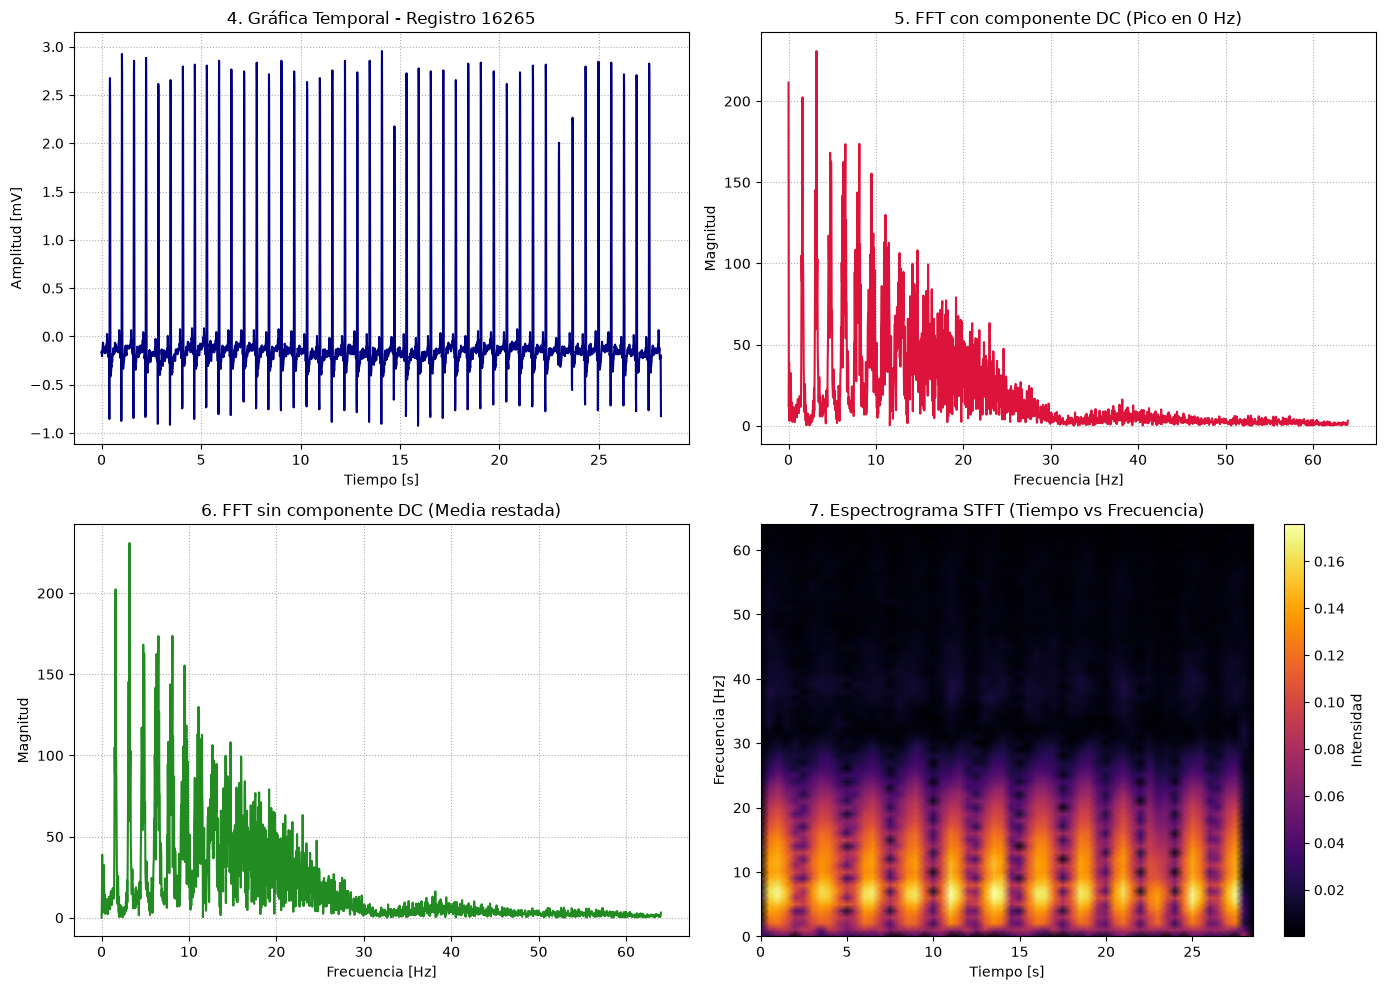

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import wfdb

RECORD_NAME = "16265"
CHANNEL = 0
SAMPLES = 3600

record = wfdb.rdrecord(RECORD_NAME, pn_dir="nsrdb", sampfrom=0, sampto=SAMPLES)
fs = record.fs
x = record.p_signal[:, CHANNEL]
t = np.arange(len(x)) / fs
freqs = np.fft.rfftfreq(len(x), d=1/fs)
fft_con_dc = np.abs(np.fft.rfft(x))

x_sin_dc = x - np.mean(x)
fft_sin_dc = np.abs(np.fft.rfft(x_sin_dc))


f_stft, t_stft, Zxx = signal.stft(x_sin_dc, fs=fs, nperseg=128, noverlap=64)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(t, x, color="navy")
plt.title(f"4. Gráfica Temporal - Registro {RECORD_NAME}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.grid(True, linestyle=":")

plt.subplot(2, 2, 2)
plt.plot(freqs, fft_con_dc, color="crimson")
plt.title("5. FFT con componente DC (Pico en 0 Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True, linestyle=":")

plt.subplot(2, 2, 3)
plt.plot(freqs, fft_sin_dc, color="forestgreen")
plt.title("6. FFT sin componente DC (Media restada)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True, linestyle=":")

plt.subplot(2, 2, 4)
plt.pcolormesh(t_stft, f_stft, np.abs(Zxx), shading="gouraud", cmap="inferno")
plt.title("7. Espectrograma STFT (Tiempo vs Frecuencia)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.colorbar(label="Intensidad")

plt.tight_layout()
plt.show()

# 17. Conclusiones esperadas

Al finalizar este ejercicio, el estudiante debe comprender que una señal biomédica puede estudiarse desde tres perspectivas complementarias:

```text
                    SEÑAL BIOMÉDICA
                           │
             ┌─────────────┼─────────────┐
             ↓             ↓             ↓
          TIEMPO       FRECUENCIA    TIEMPO-FRECUENCIA
             │             │             │
           x(t)           FFT           STFT
             │             │             │
             └─────────────┼─────────────┘
                           ↓
                  INTERPRETACIÓN
                     DE LA SEÑAL
```

La representación temporal permite observar la evolución de la amplitud; la FFT permite estudiar el contenido frecuencial global; y la STFT permite analizar cómo cambia dicho contenido con el tiempo.


# Referencias

- PhysioNet — plataforma para el acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas para lectura y procesamiento de registros fisiológicos.
- Normal Sinus Rhythm Database (NSRDB) — base de datos utilizada en este ejercicio.

> Consulte siempre la documentación de la base de datos para interpretar correctamente sus registros, canales y anotaciones.
